# В этом ноутбуке реализованы и протестированы методы, о окоторых подробно написано здесь:
1.  **SASRec: Self-Attentive Sequential Recommendation**
    *   **Ссылка на arXiv:** [https://arxiv.org/pdf/1808.09781](https://arxiv.org/pdf/1808.09781) 
    *   **Краткое описание:** Эта работа представляет модель SASRec, которая использует механизм самовнимания (self-attention) для баланса между простыми моделями (цепи Маркова) и сложными (RNN), чтобы эффективно моделировать долгосрочные зависимости в последовательностях действий пользователя .

2.  **BERT4Rec: Sequential Recommendation with Bidirectional Encoder Representations from Transformer**
    *   **Ссылка на arXiv:** [https://arxiv.org/pdf/1904.06690](https://arxiv.org/pdf/1904.06690) 
    *   **Краткое описание:** Исследователи из Alibaba адаптируют архитектуру BERT для рекомендательных систем. Модель использует двунаправленное внимание и обучается на задаче маскирования (MLM), что позволяет ей учитывать контекст с обеих сторон последовательности .

3.  **gSASRec: Reducing Overconfidence in Sequential Recommendation Trained with Negative Sampling**
    *   **Ссылка на arXiv:** [https://arxiv.org/pdf/2308.07192](https://arxiv.org/pdf/2308.07192) 
    *   **Краткое описание:** В этой статье исследуется проблема "излишней самоуверенности" (overconfidence) в моделях, обученных с использованием негативной выборки (negative sampling). Авторы предлагают новую функцию потерь gBCE и модель gSASRec, которая показывает результаты, сравнимые с BERT4Rec, но обучается быстрее .

4.  **TRON: Scaling Session-Based Transformer Recommendations using Optimized Negative Sampling and Loss Functions**
    *   **Ссылка на arXiv:** [https://arxiv.org/pdf/2307.14906](https://arxiv.org/pdf/2307.14906) 
    *   **Краткое описание:** Статья фокусируется на сессионных рекомендациях и предлагает оптимизированные методы негативной выборки и функции потерь для масштабирования Transformer-моделей .

5.  **(Дополнительная статья для проверки воспроизводимости BERT4Rec)**
    *   **Ссылка на arXiv:** [https://arxiv.org/pdf/2207.07483](https://arxiv.org/pdf/2207.07483) 
    *   **Краткое описание:** Эта работа критически пересматривает результаты оригинальной статьи BERT4Rec, указывая на сложность их воспроизведения и зависимость от конкретной реализации .


In [24]:
import os
import json
import gc
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import psutil
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Пути к данным
DATA_DIR = "/kaggle/input/datasets/f0rzah/ednet-prepared"

## Проверка ресурсов

In [25]:
ram_gb = psutil.virtual_memory().available / (1024**3)
print(f"✅ Доступно RAM: {ram_gb:.2f} ГБ")
print(f"✅ GPU доступен: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   Модель GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    print("Используем CPU")

✅ Доступно RAM: 28.60 ГБ
✅ GPU доступен: True
   Модель GPU: Tesla T4


## Загрузка данных

In [26]:
train_df = pl.read_parquet(f"{DATA_DIR}/train.parquet")
val_df = pl.read_parquet(f"{DATA_DIR}/val.parquet")
test_df = pl.read_parquet(f"{DATA_DIR}/test.parquet")

print(f"   Train: {len(train_df)} записей")
print(f"   Val:   {len(val_df)} записей")
print(f"   Test:  {len(test_df)} записей")

   Train: 50000 записей
   Val:   50000 записей
   Test:  50000 записей


In [27]:
with open(f"{DATA_DIR}/item2idx.json", "r") as f:
    item2idx = json.load(f)
with open(f"{DATA_DIR}/idx2item.json", "r") as f:
    idx2item = json.load(f)

idx2item = {int(k): v for k, v in idx2item.items()}

VOCAB_SIZE = len(item2idx)
print(f"✅ Vocab size: {VOCAB_SIZE}")

✅ Vocab size: 12081


## Задаем гиперпараметры

In [28]:
# 6. Гиперпараметры
MAX_SEQ_LEN = 50 
BATCH_SIZE = 256
EMBED_DIM = 64          # Размер эмбеддингов
NUM_HEADS = 2           # Голов attention
NUM_LAYERS = 2          # Слоев трансформера
DROPOUT = 0.2
LEARNING_RATE = 1e-3
NUM_EPOCHS = 20

print(f"\nГиперпараметры:")
print(f"   MAX_SEQ_LEN: {MAX_SEQ_LEN}")
print(f"   BATCH_SIZE: {BATCH_SIZE}")
print(f"   EMBED_DIM: {EMBED_DIM}")
print(f"   NUM_LAYERS: {NUM_LAYERS}")


Гиперпараметры:
   MAX_SEQ_LEN: 50
   BATCH_SIZE: 256
   EMBED_DIM: 64
   NUM_LAYERS: 2


## SASRecDataset

In [29]:
class SASRecDataset(Dataset):
    def __init__(self, dataframe, max_seq_len):
        self.max_seq_len = max_seq_len
        self.data = []
        for row in dataframe.iter_rows(named=True):
            self.data.append({
                'user_idx': row['user_idx'],
                'sequence': row['sequence']
            })
        print(f"   Dataset создан: {len(self.data)} примеров")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        sequence = item['sequence']
        
        if len(sequence) > self.max_seq_len:
            sequence = sequence[-self.max_seq_len:]
        
        full_history = sequence.copy()
            
        if len(sequence) < 2:
            return {
                'input_seq': [0], 
                'target': 0, 
                'length': 1, 
                'history': full_history
            }
        
        input_seq = sequence[:-1]
        target = sequence[-1]
        
        return {
            'input_seq': input_seq,
            'target': target,
            'length': len(input_seq),
            'history': full_history
        }

## TRON семплика


In [30]:
def tron_collate_fn(batch, vocab_size, num_negatives=64):
    batch = [item for item in batch if item['length'] > 1]
    if len(batch) == 0:
        return {
            'input_seq': torch.zeros(1, 1, dtype=torch.long), 
            'target': torch.zeros(1, dtype=torch.long), 
            'mask': torch.zeros(1, 1, dtype=torch.bool), 
            'negatives': torch.zeros(1, num_negatives, dtype=torch.long)
        }
    
    max_len = max(item['length'] for item in batch)
    batch_size = len(batch)
    
    input_seqs = torch.zeros(batch_size, max_len, dtype=torch.long)
    targets = torch.zeros(batch_size, dtype=torch.long)
    masks = torch.zeros(batch_size, max_len, dtype=torch.bool)
    
    for i, item in enumerate(batch):
        seq = item['input_seq']
        length = len(seq)
        input_seqs[i, :length] = torch.tensor(seq, dtype=torch.long)
        masks[i, :length] = True
        targets[i] = item['target']
    
    # --- TRON NEGATIVE SAMPLING ---
    n_random = num_negatives // 2
    n_batch = num_negatives // 4
    n_session = num_negatives - n_random - n_batch
    
    # 1. Random Sampling
    neg_random = torch.randint(2, vocab_size, (batch_size, n_random))
    
    # 2. Batch-wise Sampling
    batch_targets = targets.clone()
    neg_batch = batch_targets[torch.randint(0, batch_size, (batch_size, n_batch))]
    
    # 3. Session-wise Sampling
    neg_session = torch.zeros(batch_size, n_session, dtype=torch.long)
    for i, item in enumerate(batch):
        hist = item['history']
        if len(hist) > 0:
            idx = torch.randint(0, len(hist), (n_session,))
            neg_session[i] = torch.tensor([hist[j] for j in idx], dtype=torch.long)
        else:
            neg_session[i] = torch.randint(2, vocab_size, (n_session,))
            
    negatives = torch.cat([neg_random, neg_batch, neg_session], dim=1)
    
    return {
        'input_seq': input_seqs,
        'target': targets,
        'mask': masks,
        'negatives': negatives
    }


## Создание датасетов

In [31]:
train_dataset = SASRecDataset(train_df, MAX_SEQ_LEN)
val_dataset = SASRecDataset(val_df, MAX_SEQ_LEN)
test_dataset = SASRecDataset(test_df, MAX_SEQ_LEN)

NUM_NEGATIVES = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=lambda b: tron_collate_fn(b, VOCAB_SIZE, NUM_NEGATIVES), 
    num_workers=0
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=lambda b: tron_collate_fn(b, VOCAB_SIZE, NUM_NEGATIVES), 
    num_workers=0
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=lambda b: tron_collate_fn(b, VOCAB_SIZE, NUM_NEGATIVES), 
    num_workers=0
)

print(f"✅ DataLoader'ы созданы. Negatives per item: {NUM_NEGATIVES}")

# Тестовый прогон
sample_batch = next(iter(train_loader))
print(f"   Input shape:  {sample_batch['input_seq'].shape}")
print(f"   Target shape: {sample_batch['target'].shape}")
print(f"   Negatives shape: {sample_batch['negatives'].shape}")
print(f"   Пример negatives[0]: {sample_batch['negatives'][0, :10].tolist()}")

   Dataset создан: 50000 примеров
   Dataset создан: 50000 примеров
   Dataset создан: 50000 примеров
✅ DataLoader'ы созданы. Negatives per item: 64
   Input shape:  torch.Size([256, 49])
   Target shape: torch.Size([256])
   Negatives shape: torch.Size([256, 64])
   Пример negatives[0]: [4145, 1614, 10208, 10309, 348, 1561, 5487, 4724, 11704, 6572]


## Positional Encoding

In [32]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

## SASRec

In [33]:
class SASRec(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, max_seq_len, dropout=0.2):
        super().__init__()
        
        self.embed_dim = embed_dim
        self.num_layers = num_layers
        
        self.item_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=max_seq_len)
        
        # Transformer Encoder Layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        
        self.ln_f = nn.LayerNorm(embed_dim)
        
        self.dropout = nn.Dropout(dropout)
        
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def _generate_causal_mask(self, seq_len, device):
        mask = torch.tril(torch.ones(seq_len, seq_len, device=device)).bool()
        return mask
    
    def forward(self, input_seq, mask=None):
        batch_size, seq_len = input_seq.shape
        
        # 1. Item Embedding
        x = self.item_embedding(input_seq)  # [batch_size, seq_len, embed_dim]
        x = self.dropout(x)
        
        # 2. Positional Encoding
        x = self.pos_encoder(x)  # [batch_size, seq_len, embed_dim]
        
        # 3. Создание масок для Transformer
        
        # Causal mask
        causal_mask = self._generate_causal_mask(seq_len, input_seq.device)
        causal_mask = ~causal_mask
        
        # Padding mask (чтобы не смотреть на PAD токены)
        # Transformer ожидает: True = блокировать, False = разрешить
        if mask is not None:
            padding_mask = ~mask
        else:
            padding_mask = None
        
        # 4. Transformer Encoder
        x = self.transformer_encoder(
            x,
            mask=causal_mask,
            src_key_padding_mask=padding_mask
        )  # [batch_size, seq_len, embed_dim]
        
        # 5. Layer Normalization
        x = self.ln_f(x)
        
        # 6. Проекция на vocab_size (используем веса item_embedding - weight tying)
        logits = F.linear(x, self.item_embedding.weight)  # [batch_size, seq_len, vocab_size]
        
        return logits
    
    def get_item_embeddings(self):
        return self.item_embedding.weight.detach().cpu().numpy()


## Инициализация модели

In [34]:
model = SASRec(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    max_seq_len=MAX_SEQ_LEN,
    dropout=DROPOUT
).to(device)

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Модель создана:")
print(f"   Всего параметров: {total_params:,}")
print(f"   Обучаемых параметров: {trainable_params:,}")
print(f"   Device: {device}")

# Тестовый прогон
print("\nТестовый прогон модели:")
sample_input = sample_batch['input_seq'].to(device)
sample_mask = sample_batch['mask'].to(device)

with torch.no_grad():
    sample_output = model(sample_input, sample_mask)

print(f"   Input shape:  {sample_input.shape}")
print(f"   Output shape: {sample_output.shape}")
print(f"   Пример logits (первые 5 значений для первого токена): {sample_output[0, 0, :5].tolist()}")

✅ Модель создана:
   Всего параметров: 873,280
   Обучаемых параметров: 873,280
   Device: cuda

Тестовый прогон модели:
   Input shape:  torch.Size([256, 49])
   Output shape: torch.Size([256, 49, 12081])
   Пример logits (первые 5 значений для первого токена): [-0.06597239524126053, -0.06524480134248734, 0.040524672716856, -0.24102824926376343, 0.001043998752720654]


# gBCE loss

In [35]:
class gBCELoss(nn.Module):
    """
    Настоящий gBCE Loss.
    Считает BCE только по сэмплированным негативным примерам.
    """
    def __init__(self):
        super().__init__()
    
    def forward(self, logits, targets, negatives):
        # logits: [batch_size, vocab_size]
        # targets: [batch_size]
        # negatives: [batch_size, num_neg]
        
        pos_scores = logits.gather(1, targets.unsqueeze(1)) # [batch_size, 1]
        neg_scores = logits.gather(1, negatives)            # [batch_size, num_neg]
        
        # BCE для позитива (стремимся к 1)
        pos_loss = F.binary_cross_entropy_with_logits(pos_scores, torch.ones_like(pos_scores))
        
        # BCE для негативов (стремимся к 0)
        neg_loss = F.binary_cross_entropy_with_logits(neg_scores, torch.zeros_like(neg_scores))
        
        return pos_loss + neg_loss.mean()

## Sampled Softmax Loss

In [36]:
class SampledSoftmaxLoss(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, logits, targets, negatives):
        pos_scores = logits.gather(1, targets.unsqueeze(1)) # [batch_size, 1]
        neg_scores = logits.gather(1, negatives)            # [batch_size, num_neg]
        
        all_scores = torch.cat([pos_scores, neg_scores], dim=1) # [batch_size, 1 + num_neg]
        
        # Labels: 0 - это всегда позитивный класс (он первый в all_scores)
        labels = torch.zeros(all_scores.size(0), dtype=torch.long, device=logits.device)
        
        return F.cross_entropy(all_scores, labels)

In [37]:
# Инициализация
gbce_loss_fn = gBCELoss().to(device)
sampled_softmax_loss_fn = SampledSoftmaxLoss().to(device)
bce_loss_fn = nn.BCEWithLogitsLoss().to(device) # Оставляем для бейзлайна, но он будет игнорировать negatives

print("TRON и gSASRec инициализированы успешно")

TRON и gSASRec инициализированы успешно


# Реализация метрик


In [38]:
def hit_rate_at_k(logits, targets, k=10):
    """
    HitRate@K (векторизованная версия)
    """
    _, top_k_indices = torch.topk(logits, k, dim=1)  # [batch_size, k]
    # Расширяем targets для сравнения: [batch_size] -> [batch_size, k]
    targets_expanded = targets.unsqueeze(1).expand_as(top_k_indices)
    # Проверяем совпадения и считаем среднее
    hits = (top_k_indices == targets_expanded).any(dim=1).float()
    return hits.mean().item()


def ndcg_at_k(logits, targets, k=10):
    """
    NDCG@K (векторизованная версия)
    Учитывает позицию target в топ-K
    """
    _, top_k_indices = torch.topk(logits, k, dim=1)  # [batch_size, k]
    
    # Расширяем targets: [batch_size, k]
    targets_expanded = targets.unsqueeze(1).expand_as(top_k_indices)
    
    # Находим позиции совпадений (0 если нет совпадения)
    matches = (top_k_indices == targets_expanded).float()  # [batch_size, k]
    positions = torch.arange(1, k + 1, device=logits.device).float()  # [k]
    
    # DCG = sum(matches / log2(position + 1))
    # Для каждого примера берем максимум одно совпадение
    dcg = (matches / torch.log2(positions + 1)).sum(dim=1)  # [batch_size]
    
    # IDCG = 1.0 (так как у нас только 1 релевантный айтем)
    ndcg = dcg  # idcg = 1.0
    
    return ndcg.mean().item()

In [39]:
def evaluate_model(model, dataloader, device, k_values=[5, 10, 20]):
    """
    Полная оценка модели
    """
    model.eval()
    
    # Накопители метрик
    metrics = {f'HR@{k}': 0.0 for k in k_values}
    metrics.update({f'NDCG@{k}': 0.0 for k in k_values})
    
    num_batches = 0
    total_samples = 0
    
    with torch.no_grad():
        for batch in dataloader:
            input_seq = batch['input_seq'].to(device)
            mask = batch['mask'].to(device)
            targets = batch['target'].to(device)
            
            batch_size = targets.size(0)
            
            # Forward pass
            logits = model(input_seq, mask)
            last_logits = logits[:, -1, :]  # [batch_size, vocab_size]
            
            # Вычисляем метрики
            for k in k_values:
                metrics[f'HR@{k}'] += hit_rate_at_k(last_logits, targets, k) * batch_size
                metrics[f'NDCG@{k}'] += ndcg_at_k(last_logits, targets, k) * batch_size
            
            num_batches += 1
            total_samples += batch_size
    
    for key in metrics:
        metrics[key] /= total_samples
    
    model.train()
    return metrics


In [40]:
sample_val_batch = next(iter(val_loader))
sample_val_input = sample_val_batch['input_seq'].to(device)
sample_val_mask = sample_val_batch['mask'].to(device)
sample_val_targets = sample_val_batch['target'].to(device)

with torch.no_grad():
    sample_val_logits = model(sample_val_input, sample_val_mask)
    sample_val_last_logits = sample_val_logits[:, -1, :]

# Замер скорости
import time
start = time.time()
for _ in range(100):
    hr_10 = hit_rate_at_k(sample_val_last_logits, sample_val_targets, k=10)
    ndcg_10 = ndcg_at_k(sample_val_last_logits, sample_val_targets, k=10)
elapsed = time.time() - start

print(f"   HR@10:  {hr_10:.6f}")
print(f"   NDCG@10: {ndcg_10:.6f}")
print(f"   Скорость: 100 вызовов за {elapsed:.3f} сек ({elapsed/100*1000:.2f} мс на вызов)")


   HR@10:  0.000000
   NDCG@10: 0.000000
   Скорость: 100 вызовов за 0.202 сек (2.02 мс на вызов)


## Функции для обучения и оценки

In [41]:
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

In [42]:
def train_epoch(model, dataloader, optimizer, loss_fn, device, loss_type='bce'):
    """Обучение модели на одной эпохе"""
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch in dataloader:
        input_seq = batch['input_seq'].to(device)
        mask = batch['mask'].to(device)
        targets = batch['target'].to(device)
        negatives = batch['negatives'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_seq, mask)
        last_logits = logits[:, -1, :]
        
        if loss_type == 'bce':
            targets_one_hot = F.one_hot(targets, num_classes=VOCAB_SIZE).float()
            loss = loss_fn(last_logits, targets_one_hot)
        else:
            loss = loss_fn(last_logits, targets, negatives)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

In [43]:
def train_model(model, train_loader, val_loader, optimizer, loss_fn, device, 
                loss_type='bce', num_epochs=20, early_stopping_patience=5):
    """Полный цикл обучения модели"""
    history = {
        'train_loss': [],
        'val_hr@5': [],
        'val_hr@10': [],
        'val_hr@20': [],
        'val_ndcg@5': [],
        'val_ndcg@10': [],
        'val_ndcg@20': []
    }
    
    best_ndcg10 = 0.0
    best_epoch = 0
    patience_counter = 0
    best_model_state = None
    
    print(f"\n Начало обучения (loss_type={loss_type})...")
    print(f"   Эпох: {num_epochs}, Early stopping patience: {early_stopping_patience}")
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device, loss_type)
        history['train_loss'].append(train_loss)
        
        if (epoch + 1) % 2 == 0 or epoch == 0:
            val_metrics = evaluate_model(model, val_loader, device, k_values=[5, 10, 20])
            
            history['val_hr@5'].append(val_metrics['HR@5'])
            history['val_hr@10'].append(val_metrics['HR@10'])
            history['val_hr@20'].append(val_metrics['HR@20'])
            history['val_ndcg@5'].append(val_metrics['NDCG@5'])
            history['val_ndcg@10'].append(val_metrics['NDCG@10'])
            history['val_ndcg@20'].append(val_metrics['NDCG@20'])
            
            current_ndcg10 = val_metrics['NDCG@10']
            
            if current_ndcg10 > best_ndcg10:
                best_ndcg10 = current_ndcg10
                best_epoch = epoch + 1
                patience_counter = 0
                best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
                print(f"   ✅ Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val NDCG@10={current_ndcg10:.4f} (NEW BEST)")
            else:
                patience_counter += 1
                print(f"   ⏸️  Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val NDCG@10={current_ndcg10:.4f} (patience={patience_counter})")
                
                if patience_counter >= early_stopping_patience:
                    print(f"    Early stopping triggered at epoch {epoch+1}")
                    break
        else:
            print(f"   ⏭️  Epoch {epoch+1}: Train Loss={train_loss:.4f} (validation skipped)")
        
        elapsed = time.time() - start_time
        print(f"      Time: {elapsed:.1f}s")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Обучение завершено. Best epoch: {best_epoch}, Val NDCG@10: {best_ndcg10:.4f}")
    else:
        print(f"\n✅ Обучение завершено.")
    
    return history, model

In [44]:
def evaluate_model(model, dataloader, device, k_values=[5, 10, 20]):
    """Полная оценка модели"""
    model.eval()
    
    metrics = {f'HR@{k}': 0.0 for k in k_values}
    metrics.update({f'NDCG@{k}': 0.0 for k in k_values})
    
    num_batches = 0
    total_samples = 0
    
    with torch.no_grad():
        for batch in dataloader:
            input_seq = batch['input_seq'].to(device)
            mask = batch['mask'].to(device)
            targets = batch['target'].to(device)
            
            batch_size = targets.size(0)
            
            logits = model(input_seq, mask)
            last_logits = logits[:, -1, :]
            
            for k in k_values:
                metrics[f'HR@{k}'] += hit_rate_at_k(last_logits, targets, k) * batch_size
                metrics[f'NDCG@{k}'] += ndcg_at_k(last_logits, targets, k) * batch_size
            
            num_batches += 1
            total_samples += batch_size
    
    for key in metrics:
        metrics[key] /= total_samples
    
    model.train()
    return metrics

In [45]:
def plot_training_history(histories, labels):
    """Визуализация истории обучения"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    for history, label in zip(histories, labels):
        ax.plot(history['train_loss'], label=label, marker='o')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_title('Training Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    for history, label in zip(histories, labels):
        epochs = [(i + 1) * 2 for i in range(len(history['val_ndcg@10']))]
        ax.plot(epochs, history['val_ndcg@10'], label=label, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val NDCG@10')
    ax.set_title('Validation NDCG@10')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Обучение

DataLoader'ы созданы

 Модель 1: BCE (Regularized)

 Начало обучения (loss_type=bce)...
   Эпох: 20, Early stopping patience: 5
   ✅ Epoch 1: Train Loss=0.1745, Val NDCG@10=0.0871 (NEW BEST)
      Time: 14.7s
   ✅ Epoch 2: Train Loss=0.0415, Val NDCG@10=0.0971 (NEW BEST)
      Time: 14.8s
   ⏭️  Epoch 3: Train Loss=0.0350 (validation skipped)
      Time: 9.3s
   ⏸️  Epoch 4: Train Loss=0.0306, Val NDCG@10=0.0971 (patience=1)
      Time: 14.8s
   ⏭️  Epoch 5: Train Loss=0.0272 (validation skipped)
      Time: 9.2s
   ⏸️  Epoch 6: Train Loss=0.0242, Val NDCG@10=0.0830 (patience=2)
      Time: 14.8s
   ⏭️  Epoch 7: Train Loss=0.0211 (validation skipped)
      Time: 9.2s
   ⏸️  Epoch 8: Train Loss=0.0175, Val NDCG@10=0.0827 (patience=3)
      Time: 14.8s
   ⏭️  Epoch 9: Train Loss=0.0152 (validation skipped)
      Time: 9.2s
   ✅ Epoch 10: Train Loss=0.0138, Val NDCG@10=0.0973 (NEW BEST)
      Time: 14.8s
   ⏭️  Epoch 11: Train Loss=0.0128 (validation skipped)
      Time: 9.3s
   ⏸️  Epoch

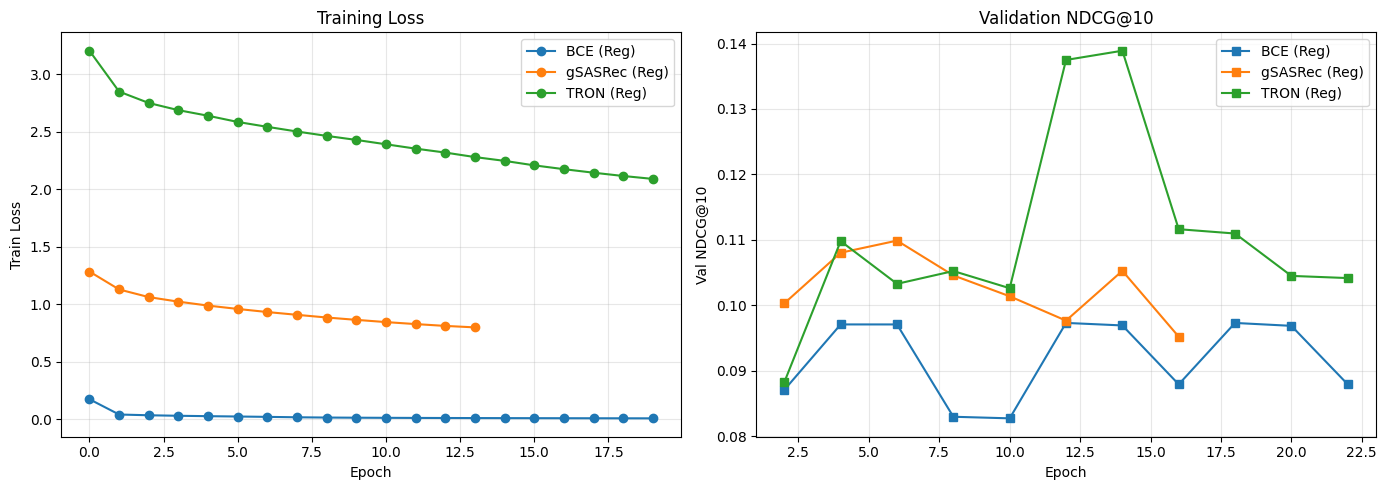


Финальные метрики на тесте (с регуляризацией):
Модель               HR@10      NDCG@10   
----------------------------------------
BCE                  0.1561     0.0852    
gSASRec              0.1647     0.1002    
TRON                 0.1509     0.1184    


In [46]:
REGULARIZED_DROPOUT = 0.5
REGULARIZED_LR = 5e-4
REGULARIZED_WEIGHT_DECAY = 1e-4
REGULARIZED_NUM_NEGATIVES = 32


train_loader_reg = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
    collate_fn=lambda b: tron_collate_fn(b, VOCAB_SIZE, REGULARIZED_NUM_NEGATIVES), num_workers=0
)
val_loader_reg = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
    collate_fn=lambda b: tron_collate_fn(b, VOCAB_SIZE, REGULARIZED_NUM_NEGATIVES), num_workers=0
)
test_loader_reg = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
    collate_fn=lambda b: tron_collate_fn(b, VOCAB_SIZE, REGULARIZED_NUM_NEGATIVES), num_workers=0
)
print(f"DataLoader'ы созданы")

print("\n Модель 1: BCE (Regularized)")
model_bce_reg = SASRec(VOCAB_SIZE, EMBED_DIM, NUM_HEADS, NUM_LAYERS, MAX_SEQ_LEN, REGULARIZED_DROPOUT).to(device)
optimizer_bce_reg = torch.optim.Adam(model_bce_reg.parameters(), lr=REGULARIZED_LR, weight_decay=REGULARIZED_WEIGHT_DECAY)
history_bce_reg, model_bce_reg = train_model(
    model_bce_reg, train_loader_reg, val_loader_reg, optimizer_bce_reg, bce_loss_fn, device,
    loss_type='bce', num_epochs=NUM_EPOCHS, early_stopping_patience=5
)

print("\n Модель 2: gSASRec (Regularized)")
model_gbce_reg = SASRec(VOCAB_SIZE, EMBED_DIM, NUM_HEADS, NUM_LAYERS, MAX_SEQ_LEN, REGULARIZED_DROPOUT).to(device)
optimizer_gbce_reg = torch.optim.Adam(model_gbce_reg.parameters(), lr=REGULARIZED_LR, weight_decay=REGULARIZED_WEIGHT_DECAY)
history_gbce_reg, model_gbce_reg = train_model(
    model_gbce_reg, train_loader_reg, val_loader_reg, optimizer_gbce_reg, gbce_loss_fn, device,
    loss_type='gbce', num_epochs=NUM_EPOCHS, early_stopping_patience=5
)

print("\n Модель 3: TRON (Regularized)")
model_tron_reg = SASRec(VOCAB_SIZE, EMBED_DIM, NUM_HEADS, NUM_LAYERS, MAX_SEQ_LEN, REGULARIZED_DROPOUT).to(device)
optimizer_tron_reg = torch.optim.Adam(model_tron_reg.parameters(), lr=REGULARIZED_LR, weight_decay=REGULARIZED_WEIGHT_DECAY)
history_tron_reg, model_tron_reg = train_model(
    model_tron_reg, train_loader_reg, val_loader_reg, optimizer_tron_reg, sampled_softmax_loss_fn, device,
    loss_type='sampled_softmax', num_epochs=NUM_EPOCHS, early_stopping_patience=5
)


plot_training_history(
    [history_bce_reg, history_gbce_reg, history_tron_reg],
    ['BCE (Reg)', 'gSASRec (Reg)', 'TRON (Reg)']
)

print("\nФинальные метрики на тесте (с регуляризацией):")
print(f"{'Модель':<20} {'HR@10':<10} {'NDCG@10':<10}")
print("-" * 40)

for name, model in [('BCE', model_bce_reg), ('gSASRec', model_gbce_reg), ('TRON', model_tron_reg)]:
    metrics = evaluate_model(model, test_loader_reg, device)
    print(f"{name:<20} {metrics['HR@10']:<10.4f} {metrics['NDCG@10']:<10.4f}")

## Сохранение

In [47]:
!pip install faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 80.3 MB/s eta 0:00:00:00:0100:01


In [48]:
import faiss
import os
import json
import torch
from pathlib import Path

# ===== 1. ФИНАЛЬНАЯ ОЦЕНКА ВСЕХ МОДЕЛЕЙ =====
print("\n📊 Финальная оценка всех моделей на тесте...")

models_to_evaluate = {
    'BCE (Reg)': model_bce_reg,
    'gSASRec (Reg)': model_gbce_reg,
    'TRON (Reg)': model_tron_reg
}

test_results = {}
for name, model in models_to_evaluate.items():
    metrics = evaluate_model(model, test_loader_reg, device, k_values=[5, 10, 20])
    test_results[name] = metrics
    print(f"   {name:<15} -> HR@10: {metrics['HR@10']:.4f}, NDCG@10: {metrics['NDCG@10']:.4f}")

# ===== 2. ВЫБОР ЛУЧШЕЙ МОДЕЛИ =====
best_model_name = max(test_results.keys(), key=lambda x: test_results[x]['NDCG@10'])
best_model = models_to_evaluate[best_model_name]
best_metrics = test_results[best_model_name]

print(f"✅ Лучшая модель: {best_model_name}")
print(f"   HR@10:  {best_metrics['HR@10']:.4f}")
print(f"   NDCG@10: {best_metrics['NDCG@10']:.4f}")

# ===== 3. ОПРЕДЕЛЕНИЕ ПАРАМЕТРОВ МОДЕЛИ =====
if "gSASRec" in best_model_name:
    model_type = "gSASRec"
    loss_type = "gbce"
    num_negatives = REGULARIZED_NUM_NEGATIVES
elif "TRON" in best_model_name:
    model_type = "TRON"
    loss_type = "sampled_softmax"
    num_negatives = REGULARIZED_NUM_NEGATIVES
else:
    model_type = "BCE"
    loss_type = "bce"
    num_negatives = 0

print(f"\nПараметры модели:")
print(f"   Тип: {model_type}")
print(f"   Loss: {loss_type}")
print(f"   Dropout: {REGULARIZED_DROPOUT}")
print(f"   Learning Rate: {REGULARIZED_LR}")
print(f"   Weight Decay: {REGULARIZED_WEIGHT_DECAY}")
print(f"   Num Negatives: {num_negatives}")

# ===== 4. СОХРАНЕНИЕ МОДЕЛИ =====
OUTPUT_DIR = "/kaggle/working/saved_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)

model_weights_path = f"{OUTPUT_DIR}/model_weights.pth"
torch.save(best_model.state_dict(), model_weights_path)
print(f"\n✅ Веса модели сохранены: {model_weights_path}")

# ===== 5. СОХРАНЕНИЕ СЛОВАРЕЙ =====
with open(f"{DATA_DIR}/item2idx.json", "r") as f:
    item2idx = json.load(f)
with open(f"{DATA_DIR}/idx2item.json", "r") as f:
    idx2item = json.load(f)
idx2item = {int(k): v for k, v in idx2item.items()}

vocab_path = f"{OUTPUT_DIR}/vocab.json"
with open(vocab_path, "w") as f:
    json.dump({"item2idx": item2idx, "idx2item": idx2item}, f)
print(f"✅ Словарь сохранен: {vocab_path}")

# ===== 6. СОЗДАНИЕ FAISS ИНДЕКСА =====
print("\n Создание FAISS индекса...")

best_model.eval()
with torch.no_grad():
    item_embeddings = best_model.item_embedding.weight.cpu().numpy()

# Исключаем PAD (0) и MASK (1) токены
item_embeddings = item_embeddings[2:]

print(f"   Размер эмбеддингов: {item_embeddings.shape}")
print(f"   Dimension: {item_embeddings.shape[1]}")

# Создаем FAISS индекс (L2 для косинусного сходства после нормализации)
dimension = item_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)

# Нормализуем векторы
faiss.normalize_L2(item_embeddings)
index.add(item_embeddings)

print(f"   ✅ Добавлено {index.ntotal} векторов в индекс")

faiss_index_path = f"{OUTPUT_DIR}/faiss_index.index"
faiss.write_index(index, faiss_index_path)
print(f"✅ FAISS индекс сохранен: {faiss_index_path}")

# ===== 7. СОХРАНЕНИЕ ГИПЕРПАРАМЕТРОВ =====
hyperparams = {
    "vocab_size": VOCAB_SIZE,
    "embed_dim": EMBED_DIM,
    "num_heads": NUM_HEADS,
    "num_layers": NUM_LAYERS,
    "max_seq_len": MAX_SEQ_LEN,
    "dropout": REGULARIZED_DROPOUT,
    "learning_rate": REGULARIZED_LR,
    "weight_decay": REGULARIZED_WEIGHT_DECAY,
    "best_model": best_model_name,
    "model_type": model_type,
    "loss_type": loss_type,
    "num_negatives": num_negatives,
    "test_metrics": {
        "HR@5": round(best_metrics['HR@5'], 4),
        "HR@10": round(best_metrics['HR@10'], 4),
        "HR@20": round(best_metrics['HR@20'], 4),
        "NDCG@5": round(best_metrics['NDCG@5'], 4),
        "NDCG@10": round(best_metrics['NDCG@10'], 4),
        "NDCG@20": round(best_metrics['NDCG@20'], 4)
    },
    "all_models_results": {
        name: {
            "HR@10": round(metrics['HR@10'], 4),
            "NDCG@10": round(metrics['NDCG@10'], 4)
        }
        for name, metrics in test_results.items()
    }
}

hyperparams_path = f"{OUTPUT_DIR}/hyperparams.json"
with open(hyperparams_path, "w") as f:
    json.dump(hyperparams, f, indent=2)
print(f"✅ Гиперпараметры сохранены: {hyperparams_path}")

# ===== 8. СОХРАНЕНИЕ ПРИМЕРОВ ДЛЯ ИНФЕРЕНСА =====
if os.path.exists(f"{DATA_DIR}/sample_inference.json"):
    with open(f"{DATA_DIR}/sample_inference.json", "r") as f:
        sample_inference = json.load(f)
    
    sample_inference_path = f"{OUTPUT_DIR}/sample_inference.json"
    with open(sample_inference_path, "w") as f:
        json.dump(sample_inference, f, indent=2)
    print(f"✅ Примеры для инференса сохранены: {sample_inference_path}")

# ===== 9. ФИНАЛЬНАЯ СТАТИСТИКА =====
print("\n" + "="*60)
print("📦 Итоговые файлы для скачивания:")
print("="*60)

total_size = 0
for filename in sorted(os.listdir(OUTPUT_DIR)):
    filepath = os.path.join(OUTPUT_DIR, filename)
    size = os.path.getsize(filepath)
    total_size += size
    print(f"   {filename:<30} {size:>10,} bytes ({size/1024:.1f} KB)")

print("-" * 60)
print(f"   {'TOTAL':<30} {total_size:>10,} bytes ({total_size/1024:.1f} KB)")


📊 Финальная оценка всех моделей на тесте...
   BCE (Reg)       -> HR@10: 0.1561, NDCG@10: 0.0852
   gSASRec (Reg)   -> HR@10: 0.1647, NDCG@10: 0.1002
   TRON (Reg)      -> HR@10: 0.1509, NDCG@10: 0.1184
✅ Лучшая модель: TRON (Reg)
   HR@10:  0.1509
   NDCG@10: 0.1184

Параметры модели:
   Тип: TRON
   Loss: sampled_softmax
   Dropout: 0.5
   Learning Rate: 0.0005
   Weight Decay: 0.0001
   Num Negatives: 32

✅ Веса модели сохранены: /kaggle/working/saved_model/model_weights.pth
✅ Словарь сохранен: /kaggle/working/saved_model/vocab.json

 Создание FAISS индекса...
   Размер эмбеддингов: (12079, 64)
   Dimension: 64
   ✅ Добавлено 12079 векторов в индекс
✅ FAISS индекс сохранен: /kaggle/working/saved_model/faiss_index.index
✅ Гиперпараметры сохранены: /kaggle/working/saved_model/hyperparams.json
✅ Примеры для инференса сохранены: /kaggle/working/saved_model/sample_inference.json

📦 Итоговые файлы для скачивания:
   faiss_index.index               3,092,269 bytes (3019.8 KB)
   hyperpara